# sc-GEM Analysis

In [2]:
cd ..

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT


/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

DATA = 'sc_GEM'


In [ ]:
ALL_CELL_STAGES = ''

In [12]:
cell_embeddings = np.load(f'./embeddings/{DATA}/mymodel_0.npy')
gene_embeddings = np.load(f'./embeddings/{DATA}/mymodel_1.npy')
omics_embeddings = np.load(f'./embeddings/{DATA}/mymodel_2.npy')
node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
cell_stage = np.unique(pd.read_csv("data/sc_GEM/cell_stage.csv", header=None))
metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [14]:
cell_stage, len(cell_stage)

(array(['BJ', 'ES', 'IPS', 'd16T+', 'd16T-', 'd24T+', 'd24T-', 'd8'],
       dtype=object),
 8)

In [15]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['BJ_1', 'BJ_11', 'BJ_12', 'BJ_13', 'BJ_14', 'BJ_15', 'BJ_17',
       'BJ_18', 'BJ_19', 'BJ_2', 'BJ_21', 'BJ_22', 'BJ_23', 'BJ_24',
       'BJ_25', 'BJ_26', 'BJ_27', 'BJ_28', 'BJ_29', 'BJ_3', 'BJ_31',
       'BJ_32', 'BJ_34', 'BJ_35', 'BJ_37', 'BJ_4', 'BJ_40', 'BJ_41',
       'BJ_43', 'BJ_44', 'BJ_46', 'BJ_5', 'BJ_7', 'BJ_8', 'BJ_9', 'ES_1',
       'ES_10', 'ES_11', 'ES_12', 'ES_13', 'ES_14', 'ES_15', 'ES_16',
       'ES_17', 'ES_18', 'ES_19', 'ES_2', 'ES_20', 'ES_21', 'ES_22',
       'ES_24', 'ES_25', 'ES_3', 'ES_4', 'ES_5', 'ES_6', 'ES_7', 'ES_8',
       'ES_9', 'IPS_1', 'IPS_10', 'IPS_11', 'IPS_12', 'IPS_13', 'IPS_16',
       'IPS_17', 'IPS_19', 'IPS_2', 'IPS_20', 'IPS_21', 'IPS_22',
       'IPS_23', 'IPS_24', 'IPS_25', 'IPS_26', 'IPS_27', 'IPS_3',
       'IPS_31', 'IPS_32', 'IPS_34', 'IPS_35', 'IPS_36', 'IPS_37',
       'IPS_38', 'IPS_39', 'IPS_4', 'IPS_40', 'IPS_44', 'IPS_45', 'IPS_5',
       'IPS_6', 'IPS_7', 'IPS_8', 'd16T+_1', 'd16T+_10', 'd16T+_11',
       'd16T+_12', 'd

In [16]:
def find_cell_stage(cell_id):
    for stage in cell_stage:
        if stage in cell_id:
            return stage
    return '??'

cell_stage_from_id = [find_cell_stage(x) for x in cell_names]

In [17]:
cell_stage_from_id

['BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16

In [18]:
# Check the stage and name.
assert len(cell_stage_from_id) == len(cell_names)

for stage, name in zip(cell_stage_from_id, cell_names):
    assert stage in name, f'stage={stage}, name={name}'

In [19]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

61

## Cell Embeddings

Text(0, 0.5, 'UMAP_2')

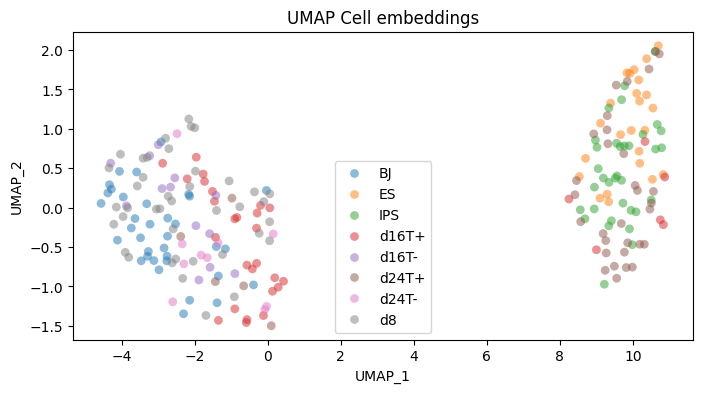

In [ ]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('Reprogramming Process')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


ES, IPS, d24T+ are in one group.

Others are in the other group.

## Heatmaps of gene embeddings

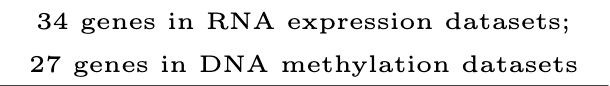

In [16]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,...,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
0,-2.307165,1.813419,1.813062,-4.741152,1.727923,6.803998,1.673647,1.939962,1.278371,0.172210,...,0.873919,0.576553,-1.492875,-0.042513,0.234944,-0.319611,0.733631,0.074568,0.518209,1.121228
1,-0.367974,-0.910620,-0.789485,0.193308,-1.588488,-14.885326,0.094215,1.048935,-0.343531,1.041057,...,-0.480600,-1.028507,0.083271,-0.388400,-0.421703,0.969218,-1.153077,-0.412276,-0.375123,-0.232961
2,0.461952,-1.916016,-0.525856,0.101079,-1.614431,5.814759,-0.679194,0.725540,-0.388151,2.249004,...,-0.527652,-0.699666,0.741376,-1.375404,-0.895716,1.503339,-0.717440,-0.497510,-0.315073,-0.405214
3,-0.186744,-0.484648,-0.645949,0.050464,-0.334977,15.669731,-0.235015,0.275101,-0.619282,0.833287,...,-0.304109,-0.227840,0.357613,-0.256403,-0.520203,0.724736,-0.316174,-0.222787,-0.339923,-0.618971
4,-1.343179,-1.278664,-0.446401,0.347292,0.093109,8.877712,-0.281638,-0.115772,-0.743577,0.974833,...,-0.716677,-1.384096,1.094936,0.683018,-0.936730,1.472407,-0.852187,0.686770,-0.030635,0.752712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-1.935613,-0.857912,-0.932442,0.390557,-1.546106,10.306317,-0.567709,-0.770656,-1.190526,1.819750,...,-0.337271,-1.089902,1.237186,-0.836239,-0.936367,1.503139,-0.870143,-0.480630,-0.348774,-0.408518
60,0.609049,-1.654693,-0.588418,0.610090,-1.780564,9.248387,-0.425378,-0.100519,-0.904606,1.944920,...,0.437853,-0.493188,2.207267,-0.569985,-0.706954,2.269061,-0.086988,0.762945,0.087509,0.296300
61,-0.026493,-0.006336,0.134605,-0.051967,-0.008176,-15.453582,-0.143842,0.435873,-0.292720,-0.803362,...,0.485356,-0.044934,0.098893,0.273695,0.039802,0.106803,0.299700,0.137677,0.419921,-0.038289
62,-0.487345,0.483566,0.178756,0.408105,0.628947,15.942610,-0.195471,-0.360674,0.415789,-0.530569,...,0.480452,0.660972,-0.405825,0.183394,0.304833,-0.487852,0.996544,0.175735,-0.202578,0.336360


In [17]:
EXPR_LIST = [
    "ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1", "IGF2", "HAND1", "TFAP2A",
    "TBX3", "FOSL1", "LUM", "TGFBR2"
]
METHY_LIST = [
    "CDH22", "KCNQ2", "NXRA8", "DPPA3", "TMEM173", "COL20A1", "TNNI3",
    "CHL1", "STON2P1", "ALDH3A1", "UNC45A", "SULT1A1", "ZNF662", "LTBR",
    "PIWIL1", "CYBRD1", "FOXD2", "HLX-AS1", "ADAM33", "NFIX", "COL23A1",
    "LY86-AS1", "NFATC1", "PLEKHH3", "TFAP2A", "EPHB3", "AK123759"
]
len(EXPR_LIST), len(METHY_LIST)

(26, 27)

## Heatmap of RNA Expression

In [18]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, EXPR_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of RNA expression on sc-GEM')

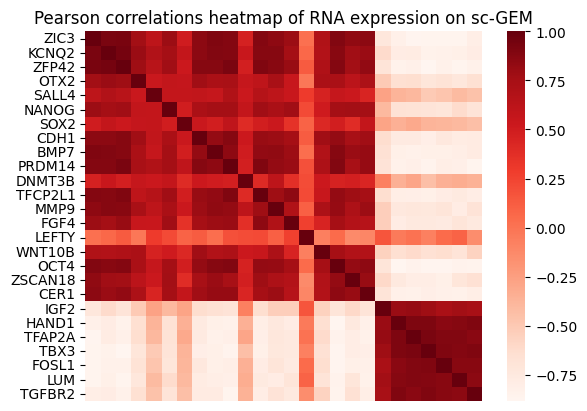

In [109]:
sns.heatmap(df_expr.corr(method='pearson'), cmap='Reds', yticklabels=EXPR_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of RNA expression on sc-GEM')

## Heatmap of DNA Methylation

In [20]:
df_methy = df_gene.loc[:, df_gene.columns.str.endswith('_methy')].rename(lambda x: x.replace('_methy', ''), axis=1)
df_methy = df_methy.loc[:, METHY_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of DNA methylation on sc-GEM')

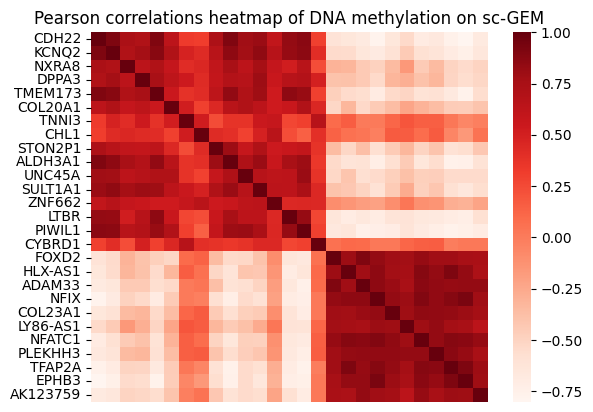

In [108]:
sns.heatmap(df_methy.corr(method='pearson'), cmap='Reds', yticklabels=METHY_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of DNA methylation on sc-GEM')

## Projection of pluripotency and somatic gene embeddings

In [22]:
pluripotency = ["ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1",]

intermedia = [
     'IGF2',
    'HAND1',
]

somatic = [
     'TFAP2A',
     'TBX3',
     'FOSL1',
     'LUM',
     'TGFBR2'
]

In [34]:
pluripotency_gene_df = df_expr.loc[:, pluripotency]
somatic_gene_df = df_expr.loc[:, somatic]

In [82]:
cell_norms = np.linalg.norm(cell_embeddings, axis=1).reshape((-1, 1))

cell_norms.shape

(224, 1)

In [83]:
cell_df = pd.DataFrame(cell_embeddings / cell_norms, index=cell_names)
cell_df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
BJ_1,-0.023597,0.092445,0.196035,0.004063,0.136019,-0.121158,-0.137753,-0.052365,-0.045836,-0.086575,...,0.017022,0.026461,0.135609,0.025837,0.024305,0.220576,0.039711,-0.028140,0.025406,0.223524
BJ_11,-0.091668,0.041837,0.091684,0.035562,0.079578,-0.128614,-0.083584,-0.081719,-0.105053,0.046956,...,0.177771,0.077297,0.077212,0.114467,0.019923,0.056198,0.091596,-0.073092,-0.029003,0.199942
BJ_12,-0.057950,0.101638,0.059302,0.038498,-0.007275,-0.186218,-0.136730,-0.130486,-0.067365,0.073795,...,0.137343,0.092168,0.014202,0.183068,-0.041770,0.173786,0.069176,0.055479,-0.064441,0.222260
BJ_13,-0.011421,0.105388,0.105429,0.036425,0.100321,-0.067725,-0.120398,-0.041115,-0.013870,-0.057600,...,0.072189,0.105234,0.107015,0.136764,0.024200,0.135874,0.091673,-0.032442,-0.049792,0.120495
BJ_14,-0.060037,0.094189,0.205727,0.052356,0.104576,-0.186528,-0.090385,-0.029754,-0.007905,-0.120152,...,0.105325,0.113851,0.140213,0.188641,0.047791,0.101516,0.176390,0.021392,0.014047,0.171812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
d8_46,0.015676,0.125983,0.066829,0.019778,0.187923,0.022524,-0.169302,-0.115062,-0.017768,0.284530,...,0.046536,0.154884,0.060296,-0.040645,-0.016999,0.085700,0.073297,0.008095,-0.034786,0.123836
d8_5,0.075991,0.125116,0.197173,0.063977,0.275318,-0.050924,-0.234751,-0.102790,0.000987,-0.066364,...,0.021712,0.048728,-0.086425,0.170929,-0.035812,0.236218,-0.019692,-0.034251,0.012165,0.149600
d8_7,0.048240,0.076430,0.142761,-0.002702,-0.010470,0.021594,-0.054043,-0.093571,-0.070654,-0.159027,...,0.225726,0.155264,0.349102,-0.066381,0.076527,0.071659,0.100085,0.055321,0.022767,0.130642
d8_8,0.154888,0.038678,0.171670,0.063326,0.140096,-0.078518,-0.166178,-0.083051,-0.042644,-0.110132,...,0.108806,0.115952,0.076423,0.182509,0.015758,0.172552,0.114241,0.022513,-0.014254,0.180824


In [86]:
np.sum(cell_df.iloc[0, :].values ** 2) # Cell embeddings normalized.

0.9999999

In [25]:
special_cell_stages = ['BJ', 'd8', 'd16', 'd24', 'IPS', 'ES']
special_cell_ids = [x for x in cell_df.index if any(stage in x for stage in special_cell_stages)]

In [50]:
special_cells_df = cell_df.loc[special_cell_ids, :].reset_index(names='cell_id')

In [52]:
def find_stage(cell_id):
    for stage in special_cell_stages:
        if stage in cell_id:
            return stage
    return '??'

special_cells_df['stage'] = special_cells_df['cell_id'].apply(find_stage)
special_cells_df = special_cells_df.drop(columns='cell_id').set_index('stage')

In [53]:
special_cells_df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
stage,,,,,,,,,,,,,,,,,,,,,
BJ,-0.115122,0.451010,0.956393,0.019820,0.663598,-0.591092,-0.672057,-0.255474,-0.223620,-0.422373,...,0.083043,0.129093,0.661594,0.126053,0.118577,1.076125,0.193736,-0.137288,0.123947,1.090506
BJ,-0.521786,0.238143,0.521879,0.202426,0.452967,-0.732086,-0.475770,-0.465156,-0.597976,0.267280,...,1.011893,0.439985,0.439501,0.651562,0.113402,0.319885,0.521376,-0.416050,-0.165090,1.138094
BJ,-0.274004,0.480570,0.280395,0.182026,-0.034399,-0.880484,-0.646492,-0.616969,-0.318519,0.348919,...,0.649393,0.435794,0.067152,0.865590,-0.197500,0.821704,0.327081,0.262316,-0.304694,1.050898
BJ,-0.083401,0.769622,0.769914,0.266002,0.732614,-0.494578,-0.879229,-0.300249,-0.101292,-0.420636,...,0.527177,0.768494,0.781496,0.998746,0.176723,0.992251,0.669462,-0.236911,-0.363617,0.879943
BJ,-0.397898,0.624239,1.363467,0.346989,0.693079,-1.236225,-0.599028,-0.197199,-0.052393,-0.796314,...,0.698049,0.754550,0.929268,1.250226,0.316737,0.672799,1.169035,0.141777,0.093099,1.138690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
d8,0.102150,0.820958,0.435485,0.128880,1.224582,0.146778,-1.103239,-0.749787,-0.115781,1.854107,...,0.303250,1.009283,0.392910,-0.264860,-0.110769,0.558454,0.477631,0.052752,-0.226678,0.806963
d8,0.266844,0.439347,0.692373,0.224656,0.966783,-0.178819,-0.824329,-0.360948,0.003464,-0.233036,...,0.076240,0.171109,-0.303482,0.600219,-0.125753,0.829483,-0.069147,-0.120271,0.042717,0.525322
d8,0.236030,0.373960,0.698504,-0.013221,-0.051226,0.105653,-0.264425,-0.457829,-0.345699,-0.778091,...,1.104440,0.759682,1.708097,-0.324789,0.374433,0.350613,0.489701,0.270676,0.111394,0.639208


### Somatic projection

In [93]:
proj_somatic = (special_cells_df @ somatic_gene_df)
proj_somatic = pd.melt(proj_somatic.reset_index(), id_vars='stage')
proj_somatic


,stage,variable,value
0,BJ,TFAP2A,34.800995
1,BJ,TFAP2A,48.458607
2,BJ,TFAP2A,36.676434
3,BJ,TFAP2A,62.610439
4,BJ,TFAP2A,57.236851
...,...,...,...
1115,d8,TGFBR2,25.299702
1116,d8,TGFBR2,21.108566
1117,d8,TGFBR2,28.775755
1118,d8,TGFBR2,38.787300


Text(0, 0.5, 'Projection value')

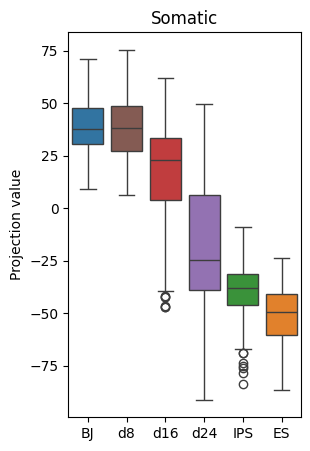

In [104]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_somatic, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Somatic')
plt.xlabel('')
plt.ylabel('Projection value')


### Pluripotency projection

In [95]:
proj_pluripotency = (special_cells_df @ pluripotency_gene_df)
proj_pluripotency = pd.melt(proj_pluripotency.reset_index(), id_vars='stage')
proj_pluripotency


,stage,variable,value
0,BJ,ZIC3,-47.254696
1,BJ,ZIC3,-55.317719
2,BJ,ZIC3,-46.472542
3,BJ,ZIC3,-77.401520
4,BJ,ZIC3,-68.465652
...,...,...,...
4251,d8,CER1,-32.184330
4252,d8,CER1,-26.598860
4253,d8,CER1,-37.774868
4254,d8,CER1,-47.455376


Text(0, 0.5, 'Projection value')

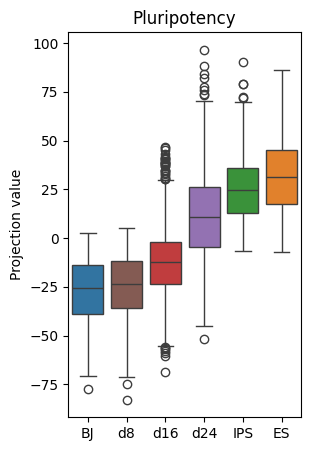

In [105]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_pluripotency, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Pluripotency')
plt.xlabel('')
plt.ylabel('Projection value')

## Cell Clustering

In [124]:
cell_stage

array(['BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ',
       'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ',
       'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ', 'BJ',
       'BJ', 'BJ', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8',
       'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8',
       'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8',
       'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd8', 'd16T-',
       'd16T-', 'd16T-', 'd16T-', 'd16T-', 'd16T-', 'd16T-', 'd16T-',
       'd16T-', 'd16T-', 'd16T-', 'd16T-', 'd16T-', 'd16T+', 'd16T+',
       'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+',
       'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+',
       'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+',
       'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+', 'd16T+',
       'd16T+', 'd16T+', 'd24T-', 'd24T-', 'd24T-', 'd24T-', 'd24T-',
  

In [ ]:
from sklearn.cluster import k_means

k_means(cell_embeddings, n_clusters=len())